In [1]:
"""
Before run this, Please click 'Restart & Clear Output' under Kernel first. 
"""

"\nBefore run this, Please click 'Restart & Clear Output' under Kernel first. \n"

In [2]:
'Random Forest'

'Random Forest'

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from collections import OrderedDict
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# X if you want to neglect the effects of 'inherited' characteristics of crystal, run this, and skip the next one;
crystal = pd.read_csv('crystal_info_no_inherited.csv')
X = crystal.values.tolist()

In [5]:
# X if you want to include the effects of 'inherited' characteristics of crystal, run this, not the above one;
crystal = pd.read_csv('crystal_info_including_inherit.csv')
X = crystal.values.tolist()

In [6]:
# y
data = pd.read_excel('41467_2021_22809_MOESM3_ESM.xlsx', sheet_name='All Structures')
gaps = []
for i in range(len(data)):
    if data.iloc[i]['Direct'] == '•' or data.iloc[i]['Inverse'] == '•':
        gaps.extend([1])
    else:
        gaps.extend([0])
y = gaps

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.1, random_state = 42, shuffle = True)
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Predict class for X
y_pred = model.predict(X_test)

score = model.score(X_test, y_test)
print("The testing accuracy of RandomFroest is :",score)

The testing accuracy of RandomFroest is : 0.8088235294117647


In [8]:
import numpy as np
# true negatives
tn = np.where(np.logical_and(model.predict(X).flatten()==0, np.array(y)==0))[0]
tp = np.where(np.logical_and(model.predict(X).flatten()==1, np.array(y)==1))[0]
fn = np.where(np.logical_and(model.predict(X).flatten()==0, np.array(y)==1))[0]
fp = np.where(np.logical_and(model.predict(X).flatten()==1, np.array(y)==0))[0]
print(len(tn), len(tp), len(fn), len(fp))

1058 166 100 32


In [9]:
import time
import numpy as np

start_time = time.time()
importances = model.feature_importances_
std = np.std([tree.feature_importances_ for tree in model.estimators_], axis = 0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.021 seconds


In [12]:
new_importances = [sum(i for i in importances[0:227]),
                          sum(i for i in importances[227:259]),
                          sum(i for i in importances[259:291]),
                          sum(i for i in importances[291:323]),
                          sum(i for i in importances[323:355]),
                          sum(i for i in importances[355:361]),
                          sum(i for i in importances[361:361])]
feature_col = ['Space Group','Global Point Group','Inherited Global Point Group','Local Points Group','Inherited Local Point Group','Lattice Type','Centering']

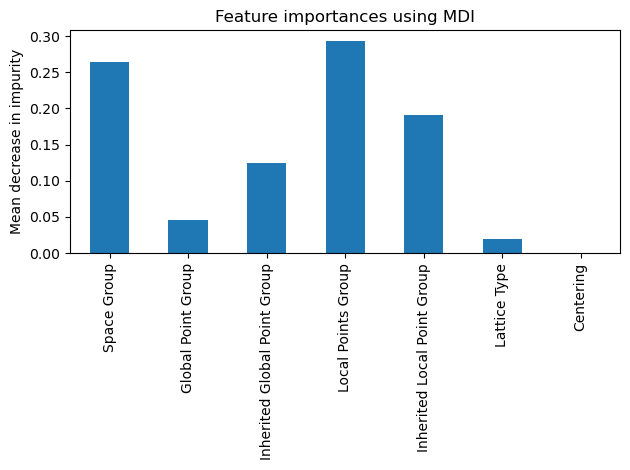

In [13]:
import pandas as pd

model_importances = pd.Series(new_importances, index=feature_col)

fig, ax = plt.subplots()
model_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [14]:
'SVM method'

'SVM method'

In [15]:
from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [16]:
svc = SVC(kernel='linear', class_weight='balanced')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)

In [17]:
tn = np.where(np.logical_and(svc.predict(X).flatten()==0, np.array(y)==0))[0]
tp = np.where(np.logical_and(svc.predict(X).flatten()==1, np.array(y)==1))[0]
fn = np.where(np.logical_and(svc.predict(X).flatten()==0, np.array(y)==1))[0]
fp = np.where(np.logical_and(svc.predict(X).flatten()==1, np.array(y)==0))[0]
print(len(tn), len(tp), len(fn), len(fp))

853 219 47 237


In [18]:
score = svc.score(X_test,y_test)
print("The testing accuracy of SVC(Support Vector Classification) is :",score)

The testing accuracy of SVC(Support Vector Classification) is : 0.6985294117647058


In [19]:
'NB method'

'NB method'

In [20]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

In [21]:
tn = np.where(np.logical_and(gnb.predict(X).flatten()==0, np.array(y)==0))[0]
tp = np.where(np.logical_and(gnb.predict(X).flatten()==1, np.array(y)==1))[0]
fn = np.where(np.logical_and(gnb.predict(X).flatten()==0, np.array(y)==1))[0]
fp = np.where(np.logical_and(gnb.predict(X).flatten()==1, np.array(y)==0))[0]
print(len(tn), len(tp), len(fn), len(fp))

513 260 6 577


In [22]:
score = gnb.score(X_test,y_test)
print("The testing accuracy of NB(Näive bayes) is :",score)

The testing accuracy of NB(Nive bayes) is : 0.5514705882352942
